In [1]:
pip install pandas numpy scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
from collections import defaultdict

import gc
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import tensorflow.keras.backend as K

from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, average_precision_score, roc_auc_score

seed = 9001
np.random.seed(seed)
tf.keras.utils.set_random_seed(seed)

2026-05-08 13:52:08.323164: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778248328.567351      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778248328.632245      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778248329.180633      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778248329.180677      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778248329.180681      57 computation_placer.cc:177] computation placer alr

In [3]:
INPUT_PATH = "/kaggle/input/datasets/thuhiuhong/traintestval-lstm"

X_train = np.load(os.path.join(INPUT_PATH, 'X_train (1).npy'))
y_train = np.load(os.path.join(INPUT_PATH, 'y_train (1).npy'))
id_train = np.load(os.path.join(INPUT_PATH, 'id_train (1).npy'), allow_pickle=True)

X_val = np.load(os.path.join(INPUT_PATH, 'X_val (1).npy'))
y_val = np.load(os.path.join(INPUT_PATH, 'y_val (1).npy'))
id_val = np.load(os.path.join(INPUT_PATH, 'id_val (1).npy'), allow_pickle=True)

X_test = np.load(os.path.join(INPUT_PATH, 'X_test (1).npy'))
y_test = np.load(os.path.join(INPUT_PATH, 'y_test (1).npy'))
id_test = np.load(os.path.join(INPUT_PATH, 'id_test (1).npy'), allow_pickle=True)

In [4]:
print("Train:", X_train.shape, y_train.shape, id_train.shape)
print("Val  :", X_val.shape, y_val.shape, id_val.shape)
print("Test :", X_test.shape, y_test.shape, id_test.shape)

print("Unique train patients:", len(np.unique(id_train)))
print("Unique val patients  :", len(np.unique(id_val)))
print("Unique test patients :", len(np.unique(id_test)))

Train: (145772, 10, 133) (145772,) (145772,)
Val  : (190797, 10, 133) (190797,) (190797,)
Test : (238447, 10, 133) (238447,) (238447,)
Unique train patients: 25456
Unique val patients  : 6352
Unique test patients : 7964


In [5]:
X_train = np.asarray(X_train).astype(np.float32)
X_val   = np.asarray(X_val).astype(np.float32)
X_test  = np.asarray(X_test).astype(np.float32)

y_train = np.asarray(y_train).astype(np.int32).reshape(-1)
y_val   = np.asarray(y_val).astype(np.int32).reshape(-1)
y_test  = np.asarray(y_test).astype(np.int32).reshape(-1)

print("X_train:", X_train.shape, X_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)
print("X_val:  ", X_val.shape, X_val.dtype)
print("y_val:  ", y_val.shape, y_val.dtype)
print("X_test: ", X_test.shape, X_test.dtype)
print("y_test: ", y_test.shape, y_test.dtype)

# Ensure all feature tensors are 3-dimensional:
# (samples, timesteps, features)
assert X_train.ndim == 3, f"X_train must be 3D, got {X_train.ndim}D"
assert X_val.ndim == 3, f"X_val must be 3D, got {X_val.ndim}D"
assert X_test.ndim == 3, f"X_test must be 3D, got {X_test.ndim}D"

# Ensure feature arrays and label arrays have matching sample counts
assert len(X_train) == len(y_train), "Mismatch between X_train and y_train sample counts"
assert len(X_val) == len(y_val), "Mismatch between X_val and y_val sample counts"
assert len(X_test) == len(y_test), "Mismatch between X_test and y_test sample counts"

print("timesteps =", X_train.shape[1])
print("n_features =", X_train.shape[2])
print("Train class distribution:", np.bincount(y_train))
print("Val class distribution:", np.bincount(y_val))
print("Test class distribution:", np.bincount(y_test))

X_train: (145772, 10, 133) float32
y_train: (145772,) int32
X_val:   (190797, 10, 133) float32
y_val:   (190797,) int32
X_test:  (238447, 10, 133) float32
y_test:  (238447,) int32
timesteps = 10
n_features = 133
Train class distribution: [134796  10976]
Val class distribution: [187169   3628]
Test class distribution: [234296   4151]


In [6]:
MODULE_PATH = "/kaggle/input/datasets/thuhiuhong/lstm-utils"
if MODULE_PATH not in sys.path:
    sys.path.append(MODULE_PATH)

from model_utils import (
    create_bilstm,
    get_callbacks,
    find_best_threshold,
    full_evaluation,
)

In [7]:
# Create a separate search-validation split from the training set
SEARCH_VAL_FRAC = 0.15
SEARCH_SPLIT_SEED = 2026

gss_search = GroupShuffleSplit(
    n_splits=1,
    test_size=SEARCH_VAL_FRAC,
    random_state=SEARCH_SPLIT_SEED
)

search_train_idx, search_val_idx = next(
    gss_search.split(X_train, y_train, groups=id_train)
)

X_search_train = X_train[search_train_idx]
y_search_train = y_train[search_train_idx]
id_search_train = id_train[search_train_idx]

X_search_val = X_train[search_val_idx]
y_search_val = y_train[search_val_idx]
id_search_val = id_train[search_val_idx]

print("SEARCH TRAIN:", X_search_train.shape, y_search_train.shape, len(np.unique(id_search_train)), "patients")
print("SEARCH VAL  :", X_search_val.shape, y_search_val.shape, len(np.unique(id_search_val)), "patients")

# Build patient-level labels for the search split
search_patient_labels = defaultdict(int)
for pid, y in zip(id_search_train, y_search_train):
    search_patient_labels[pid] = max(search_patient_labels[pid], int(y))

search_train_patient_ids = np.array(sorted(search_patient_labels.keys()))
search_pos_patients = np.array([pid for pid in search_train_patient_ids if search_patient_labels[pid] == 1])
search_neg_patients = np.array([pid for pid in search_train_patient_ids if search_patient_labels[pid] == 0])

print("SEARCH train patients:", len(search_train_patient_ids))
print("SEARCH positive patients:", len(search_pos_patients))
print("SEARCH negative patients:", len(search_neg_patients))

SEARCH TRAIN: (124113, 10, 133) (124113,) 21637 patients
SEARCH VAL  : (21659, 10, 133) (21659,) 3819 patients
SEARCH train patients: 21637
SEARCH positive patients: 1415
SEARCH negative patients: 20222


### FIND HYPERPARAMETERS FOR ENSEMBLE

In [8]:
# Hyperparameter search configuration

# Focus on the range that showed good performance in previous runs
CANDIDATES = [
    {"units": 32,  "dropout": 0.3, "batch_size": 512},
    {"units": 48,  "dropout": 0.3, "batch_size": 512},
    {"units": 64,  "dropout": 0.3, "batch_size": 256},
    {"units": 64,  "dropout": 0.4, "batch_size": 256},
    {"units": 80,  "dropout": 0.4, "batch_size": 256},
]

OUTER_SUBSET_SEEDS = [42, 52, 62, 72, 82]
SEARCH_N_MODELS = 5
SEARCH_SEEDS = [42, 52, 62, 72, 82]
SEARCH_EPOCHS = 50
EPOCHS = 50

# Final ensemble configuration
N_MODELS = 5
SEEDS = [42, 52, 62, 72, 82]
NEG_SUBSET_FRAC = 0.9

# These values will be set after hyperparameter search
BEST_UNITS = None
BEST_DROPOUT = None
BEST_BATCH_SIZE = None

print("Hyperparameter search config loaded.")
print("Candidates:")
for cfg in CANDIDATES:
    print(cfg)

print("\nOUTER_SUBSET_SEEDS =", OUTER_SUBSET_SEEDS)
print("SEARCH_N_MODELS     =", SEARCH_N_MODELS)
print("SEARCH_SEEDS        =", SEARCH_SEEDS)
print("SEARCH_EPOCHS       =", SEARCH_EPOCHS)
print("EPOCHS (final)      =", EPOCHS)
print("N_MODELS (final)    =", N_MODELS)
print("SEEDS (final)       =", SEEDS)
print("NEG_SUBSET_FRAC     =", NEG_SUBSET_FRAC)

Hyperparameter search config loaded.
Candidates:
{'units': 32, 'dropout': 0.3, 'batch_size': 512}
{'units': 48, 'dropout': 0.3, 'batch_size': 512}
{'units': 64, 'dropout': 0.3, 'batch_size': 256}
{'units': 64, 'dropout': 0.4, 'batch_size': 256}
{'units': 80, 'dropout': 0.4, 'batch_size': 256}

OUTER_SUBSET_SEEDS = [42, 52, 62, 72, 82]
SEARCH_N_MODELS     = 5
SEARCH_SEEDS        = [42, 52, 62, 72, 82]
SEARCH_EPOCHS       = 50
EPOCHS (final)      = 50
N_MODELS (final)    = 5
SEEDS (final)       = [42, 52, 62, 72, 82]
NEG_SUBSET_FRAC     = 0.9


In [9]:
PATIENT_SUBSET_SEED = 42

assert len(SEEDS) == N_MODELS, "SEEDS and N_MODELS must match."

# patient-level label 
# Treat a patient as positive if at least one sequence label is positive.
patient_labels = defaultdict(int)

for pid, y in zip(id_train, y_train):
    patient_labels[pid] = max(patient_labels[pid], int(y))

train_patient_ids = np.array(sorted(patient_labels.keys()))
pos_patients = np.array([pid for pid in train_patient_ids if patient_labels[pid] == 1])
neg_patients = np.array([pid for pid in train_patient_ids if patient_labels[pid] == 0])

print("Total train patients:", len(train_patient_ids))
print("Positive patients   :", len(pos_patients))
print("Negative patients   :", len(neg_patients))

def make_patient_subsets_all_pos(
    pos_patients,
    neg_patients,
    n_models=5,
    neg_frac=0.9,
    seed=42
):
    subsets = []
    neg_counts = []

    n_neg = max(1, int(len(neg_patients) * neg_frac))

    for i in range(n_models):
        rng = np.random.default_rng(seed + i)

        sub_pos = np.array(pos_patients, copy=True)
        sub_neg = rng.choice(neg_patients, size=n_neg, replace=False)

        subset_ids = np.concatenate([sub_pos, sub_neg])
        rng.shuffle(subset_ids)

        subsets.append(subset_ids)
        neg_counts.append(len(sub_neg))

    return subsets, n_neg, neg_counts

patient_subsets, n_neg_per_member, neg_counts = make_patient_subsets_all_pos(
    pos_patients=pos_patients,
    neg_patients=neg_patients,
    n_models=N_MODELS,
    neg_frac=NEG_SUBSET_FRAC,
    seed=PATIENT_SUBSET_SEED
)

print(f"- Subset only negative patients with NEG_SUBSET_FRAC = {NEG_SUBSET_FRAC}")
print(f"- Negative patients per member = {n_neg_per_member}")

for i, subset_ids in enumerate(patient_subsets):
    unique_ids = np.unique(subset_ids)
    n_pos_in_subset = np.intersect1d(unique_ids, pos_patients).size
    n_neg_in_subset = np.intersect1d(unique_ids, neg_patients).size
    print(
        f"Model {i+1}: total={len(unique_ids)} patients | "
        f"pos={n_pos_in_subset} | neg={n_neg_in_subset}"
    )

Total train patients: 25456
Positive patients   : 1650
Negative patients   : 23806
- Subset only negative patients with NEG_SUBSET_FRAC = 0.9
- Negative patients per member = 21425
Model 1: total=23075 patients | pos=1650 | neg=21425
Model 2: total=23075 patients | pos=1650 | neg=21425
Model 3: total=23075 patients | pos=1650 | neg=21425
Model 4: total=23075 patients | pos=1650 | neg=21425
Model 5: total=23075 patients | pos=1650 | neg=21425


In [10]:
def run_full_ensemble_val_search_for_config(cfg):
    """
    Repeated full-ensemble validation search
    - use SEARCH split only
    - do not use X_val / X_test
    - use the same ensemble size and epoch budget as the final setup
    """
    
    outer_rows = []

    for outer_subset_seed in OUTER_SUBSET_SEEDS:
        print("\n" + "="*90)
        print(
            f"FULL SEARCH | units={cfg['units']} | "
            f"dropout={cfg['dropout']} | batch={cfg['batch_size']} | "
            f"outer_subset_seed={outer_subset_seed}"
        )
        print("="*90)

        search_patient_subsets, _, _ = make_patient_subsets_all_pos(
            pos_patients=search_pos_patients,
            neg_patients=search_neg_patients,
            n_models=SEARCH_N_MODELS,
            neg_frac=NEG_SUBSET_FRAC,
            seed=outer_subset_seed
        )

        val_probs_list = []
        member_rows = []

        for member_idx, seed in enumerate(SEARCH_SEEDS, start=1):
            print("\n" + "-"*70)
            print(f"SEARCH MEMBER {member_idx}/{SEARCH_N_MODELS} | seed={seed}")
            print("-"*70)

            K.clear_session()
            np.random.seed(seed)
            tf.keras.utils.set_random_seed(seed)

            subset_patient_ids = search_patient_subsets[member_idx - 1]
            train_mask = np.isin(id_search_train, subset_patient_ids)

            X_train_sub = X_search_train[train_mask]
            y_train_sub = y_search_train[train_mask]
            id_train_sub = id_search_train[train_mask]

            unique_subset_ids = np.unique(id_train_sub)
            n_pos_subset = np.intersect1d(unique_subset_ids, search_pos_patients).size
            n_neg_subset = np.intersect1d(unique_subset_ids, search_neg_patients).size

            print(f"Subset patients : {len(unique_subset_ids)}")
            print(f"  - positive patients kept : {n_pos_subset}/{len(search_pos_patients)}")
            print(f"  - negative patients used : {n_neg_subset}/{len(search_neg_patients)}")
            print(f"Subset samples  : {len(X_train_sub)}")
            print(f"Positive rate   : {y_train_sub.mean():.6f}")

            subset_classes = np.unique(y_train_sub)
            subset_class_weights = compute_class_weight(
                class_weight='balanced',
                classes=subset_classes,
                y=y_train_sub
            )
            class_weights_dict_sub = {
                int(cls): float(w) for cls, w in zip(subset_classes, subset_class_weights)
            }

            model = create_bilstm(
                n_units=cfg["units"],
                dropout=cfg["dropout"],
                seq_len=X_train.shape[1],
                n_features=X_train.shape[2],
                lr=1e-3
            )

            ckpt_path = (
                f"/kaggle/working/search_u{cfg['units']}_d{cfg['dropout']}_"
                f"b{cfg['batch_size']}_outer{outer_subset_seed}_member{member_idx}.keras"
            )
            callbacks = get_callbacks(
                checkpoint_path=ckpt_path,
                monitor='val_auprc'
            )

            history = model.fit(
                X_train_sub, y_train_sub,
                validation_data=(X_search_val, y_search_val),
                epochs=SEARCH_EPOCHS,
                batch_size=cfg["batch_size"],
                class_weight=class_weights_dict_sub,
                shuffle=True,
                callbacks=callbacks,
                verbose=0
            )

            # Load the best checkpoint before prediction
            model.load_weights(ckpt_path)
            val_prob = model.predict(X_search_val, verbose=0).ravel()
            val_probs_list.append(val_prob)

            if "val_auprc" in history.history and len(history.history["val_auprc"]) > 0:
                best_epoch = int(np.argmax(history.history["val_auprc"]) + 1)
                best_idx = best_epoch - 1
                member_val_auprc = float(history.history["val_auprc"][best_idx])
                member_val_auroc = float(history.history["val_auroc"][best_idx])
            else:
                member_val_auprc = average_precision_score(y_search_val, val_prob)
                member_val_auroc = roc_auc_score(y_search_val, val_prob)

            print(f"member best val AUROC={member_val_auroc:.4f} | best val AUPRC={member_val_auprc:.4f}")

            member_rows.append({
                "member": member_idx,
                "val_auprc": member_val_auprc,
                "val_auroc": member_val_auroc
            })

            del model, history, X_train_sub, y_train_sub, id_train_sub
            gc.collect()

        val_probs_array = np.vstack(val_probs_list)
        df_members_local = pd.DataFrame(member_rows)

        member_weights = df_members_local["val_auprc"].to_numpy(dtype=float)
        if np.any(np.isnan(member_weights)) or member_weights.sum() <= 0:
            member_weights = np.ones(len(df_members_local), dtype=float)
        member_weights = member_weights / member_weights.sum()

        ensemble_val_prob = np.average(val_probs_array, axis=0, weights=member_weights)
        ensemble_val_auprc = average_precision_score(y_search_val, ensemble_val_prob)
        ensemble_val_auroc = roc_auc_score(y_search_val, ensemble_val_prob)

        print("\n>>> SEARCH VALIDATION RESULT")
        print(f"Ensemble search-val AUROC : {ensemble_val_auroc:.4f}")
        print(f"Ensemble search-val AUPRC : {ensemble_val_auprc:.4f}")

        outer_rows.append({
            "units": cfg["units"],
            "dropout": cfg["dropout"],
            "batch_size": cfg["batch_size"],
            "outer_subset_seed": outer_subset_seed,
            "ensemble_val_auprc": float(ensemble_val_auprc),
            "ensemble_val_auroc": float(ensemble_val_auroc),
        })

    return pd.DataFrame(outer_rows)

In [11]:
all_search_runs = []

for cfg in CANDIDATES:
    df_cfg = run_full_ensemble_val_search_for_config(cfg)
    all_search_runs.append(df_cfg)

df_full_search_runs = pd.concat(all_search_runs, ignore_index=True)

summary = (
    df_full_search_runs
    .groupby(["units", "dropout", "batch_size"], as_index=False)
    .agg(
        mean_ensemble_val_auprc=("ensemble_val_auprc", "mean"),
        std_ensemble_val_auprc=("ensemble_val_auprc", "std"),
        mean_ensemble_val_auroc=("ensemble_val_auroc", "mean"),
        std_ensemble_val_auroc=("ensemble_val_auroc", "std"),
        n_runs=("ensemble_val_auprc", "count"),
    )
)

summary["std_ensemble_val_auprc"] = summary["std_ensemble_val_auprc"].fillna(0.0)
summary["std_ensemble_val_auroc"] = summary["std_ensemble_val_auroc"].fillna(0.0)

# Main metric: AUPRC, followed by standard deviation, then AUROC

summary = summary.sort_values(
    by=["mean_ensemble_val_auprc", "std_ensemble_val_auprc", "mean_ensemble_val_auroc"],
    ascending=[False, True, False]
).reset_index(drop=True)

best_cfg = summary.iloc[0].to_dict()

BEST_UNITS = int(best_cfg["units"])
BEST_DROPOUT = float(best_cfg["dropout"])
BEST_BATCH_SIZE = int(best_cfg["batch_size"])

print("\n=== FULL SEARCH RUNS ===")
print(df_full_search_runs)

print("\n=== SEARCH SUMMARY ===")
print(summary)

print("\n=== CHOSEN BEST CONFIG ===")
print(f"BEST_UNITS      = {BEST_UNITS}")
print(f"BEST_DROPOUT    = {BEST_DROPOUT}")
print(f"BEST_BATCH_SIZE = {BEST_BATCH_SIZE}")


FULL SEARCH | units=32 | dropout=0.3 | batch=512 | outer_subset_seed=42

----------------------------------------------------------------------
SEARCH MEMBER 1/5 | seed=42
----------------------------------------------------------------------
Subset patients : 19614
  - positive patients kept : 1415/1415
  - negative patients used : 18199/20222
Subset samples  : 113708
Positive rate   : 0.083407


I0000 00:00:1778248383.495756      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778248383.501618      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1778248391.951448     114 cuda_dnn.cc:529] Loaded cuDNN version 91002



Epoch 1: val_auprc improved from -inf to 0.29878, saving model to /kaggle/working/search_u32_d0.3_b512_outer42_member1.keras

Epoch 2: val_auprc improved from 0.29878 to 0.36299, saving model to /kaggle/working/search_u32_d0.3_b512_outer42_member1.keras

Epoch 3: val_auprc improved from 0.36299 to 0.37530, saving model to /kaggle/working/search_u32_d0.3_b512_outer42_member1.keras

Epoch 4: val_auprc improved from 0.37530 to 0.38850, saving model to /kaggle/working/search_u32_d0.3_b512_outer42_member1.keras

Epoch 5: val_auprc did not improve from 0.38850

Epoch 6: val_auprc did not improve from 0.38850

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 7: val_auprc did not improve from 0.38850

Epoch 8: val_auprc did not improve from 0.38850

Epoch 9: val_auprc did not improve from 0.38850

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 10: val_auprc did not improve from 0.38850

Epoch 11: val_auprc did not improve 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epoch 1: val_auprc improved from -inf to 0.29336, saving model to /kaggle/working/search_u32_d0.3_b512_outer42_member2.keras

Epoch 2: val_auprc improved from 0.29336 to 0.34316, saving model to /kaggle/working/search_u32_d0.3_b512_outer42_member2.keras

Epoch 3: val_auprc improved from 0.34316 to 0.37298, saving model to /kaggle/working/search_u32_d0.3_b512_outer42_member2.keras

Epoch 4: val_auprc improved from 0.37298 to 0.37731, saving model to /kaggle/working/search_u32_d0.3_b512_outer42_member2.keras

Epoch 5: val_auprc did not improve from 0.37731

Epoch 6: val_auprc did not improve from 0.37731

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 7: val_auprc did not improve from 0.37731

Epoch 8: val_auprc did not improve from 0.37731

Epoch 9: val_auprc did not improve from 0.37731

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 10: val_auprc did not improve from 0.37731

Epoch 11: val_auprc did not improve 

...


Epoch 1: val_auprc improved from -inf to 0.31083, saving model to /kaggle/working/search_u80_d0.4_b256_outer82_member3.keras

Epoch 2: val_auprc improved from 0.31083 to 0.38550, saving model to /kaggle/working/search_u80_d0.4_b256_outer82_member3.keras

Epoch 3: val_auprc did not improve from 0.38550

Epoch 4: val_auprc did not improve from 0.38550

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 5: val_auprc did not improve from 0.38550

Epoch 6: val_auprc did not improve from 0.38550

Epoch 7: val_auprc did not improve from 0.38550

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 8: val_auprc did not improve from 0.38550

Epoch 9: val_auprc did not improve from 0.38550

Epoch 10: val_auprc did not improve from 0.38550
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 2.
member best val AUROC=0.8397 | best val AUPRC=0.3855

------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epoch 1: val_auprc improved from -inf to 0.33630, saving model to /kaggle/working/search_u80_d0.4_b256_outer82_member4.keras

Epoch 2: val_auprc improved from 0.33630 to 0.36032, saving model to /kaggle/working/search_u80_d0.4_b256_outer82_member4.keras

Epoch 3: val_auprc did not improve from 0.36032

Epoch 4: val_auprc did not improve from 0.36032

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 5: val_auprc did not improve from 0.36032

Epoch 6: val_auprc did not improve from 0.36032

Epoch 7: val_auprc did not improve from 0.36032

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 8: val_auprc did not improve from 0.36032

Epoch 9: val_auprc did not improve from 0.36032

Epoch 10: val_auprc did not improve from 0.36032
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 2.
member best val AUROC=0.8344 | best val AUPRC=0.3603

------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epoch 1: val_auprc improved from -inf to 0.32780, saving model to /kaggle/working/search_u80_d0.4_b256_outer82_member5.keras

Epoch 2: val_auprc improved from 0.32780 to 0.36458, saving model to /kaggle/working/search_u80_d0.4_b256_outer82_member5.keras

Epoch 3: val_auprc improved from 0.36458 to 0.39697, saving model to /kaggle/working/search_u80_d0.4_b256_outer82_member5.keras

Epoch 4: val_auprc did not improve from 0.39697

Epoch 5: val_auprc did not improve from 0.39697

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 6: val_auprc did not improve from 0.39697

Epoch 7: val_auprc did not improve from 0.39697

Epoch 8: val_auprc did not improve from 0.39697

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 9: val_auprc did not improve from 0.39697

Epoch 10: val_auprc did not improve from 0.39697

Epoch 11: val_auprc did not improve from 0.39697
Epoch 11: early stopping
Restoring model weights from the end of the

### TRAIN ENSEMBLE MEMBERS

In [12]:
val_probs_list = []
test_probs_list = []
member_summaries = []

for member_idx, seed in enumerate(SEEDS, start=1):
    print("\n" + "="*70)
    print(f"TRAINING ENSEMBLE MEMBER {member_idx}/{N_MODELS} | seed={seed}")
    print("="*70)

    K.clear_session()
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

    # 1) Get the patient subset for the current member
    subset_patient_ids = patient_subsets[member_idx - 1]

    train_mask = np.isin(id_train, subset_patient_ids)

    X_train_sub = X_train[train_mask]
    y_train_sub = y_train[train_mask]
    id_train_sub = id_train[train_mask]

    unique_subset_ids = np.unique(id_train_sub)
    n_pos_subset = np.intersect1d(unique_subset_ids, pos_patients).size
    n_neg_subset = np.intersect1d(unique_subset_ids, neg_patients).size

    print(f"Subset patients : {len(unique_subset_ids)}")
    print(f"  - positive patients kept : {n_pos_subset}/{len(pos_patients)}")
    print(f"  - negative patients used : {n_neg_subset}/{len(neg_patients)}")
    print(f"Subset samples  : {len(X_train_sub)}")
    print(f"Positive rate   : {y_train_sub.mean():.6f}")

    # 2) Compute class weights for the current subset
    subset_classes = np.unique(y_train_sub)
    subset_class_weights = compute_class_weight(
        class_weight='balanced',
        classes=subset_classes,
        y=y_train_sub
    )
    class_weights_dict_sub = {
        int(cls): float(w) for cls, w in zip(subset_classes, subset_class_weights)
    }

    print("Class weights   :", class_weights_dict_sub)

    # 3) Create model from model_utils.py
    model = create_bilstm(
        n_units=BEST_UNITS,
        dropout=BEST_DROPOUT,
        seq_len=X_train.shape[1],
        n_features=X_train.shape[2],
        lr=1e-3
    )

    # 4) Standard callbacks for each member
    ckpt_path = f'best_ensemble_member_{member_idx}.keras'
    callbacks = get_callbacks(
        checkpoint_path=ckpt_path,
        monitor='val_auprc'
    )

    # 5) Train on the subset
    history = model.fit(
        X_train_sub, y_train_sub,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BEST_BATCH_SIZE,
        class_weight=class_weights_dict_sub,
        shuffle=True,
        callbacks=callbacks,
        verbose=1
    )

    # 6) Load the best checkpoint before prediction
    model.load_weights(ckpt_path)
    val_prob = model.predict(X_val, verbose=0).ravel()
    test_prob = model.predict(X_test, verbose=0).ravel()

    val_probs_list.append(val_prob)
    test_probs_list.append(test_prob)

    # 7) Get the best epoch based on val_auprc
    if "val_auprc" in history.history and len(history.history["val_auprc"]) > 0:
        best_epoch = int(np.argmax(history.history["val_auprc"]) + 1)
        best_idx = best_epoch - 1
        best_val_auprc = float(np.max(history.history["val_auprc"]))
    else:
        best_epoch = None
        best_idx = -1
        best_val_auprc = np.nan

    # 8) Store summary information for each member
    member_summary = {
        "member": member_idx,
        "seed": seed,
        "n_subset_patients": len(unique_subset_ids),
        "n_positive_patients": int(n_pos_subset),
        "n_negative_patients": int(n_neg_subset),
        "n_subset_samples": len(X_train_sub),
        "positive_rate": float(y_train_sub.mean()),
        "best_epoch": best_epoch,
        "val_loss": history.history["val_loss"][best_idx] if "val_loss" in history.history and best_idx >= 0 else np.nan,
        "val_accuracy": history.history["val_accuracy"][best_idx] if "val_accuracy" in history.history and best_idx >= 0 else np.nan,
        "val_auroc": history.history["val_auroc"][best_idx] if "val_auroc" in history.history and best_idx >= 0 else np.nan,
        "val_auprc": history.history["val_auprc"][best_idx] if "val_auprc" in history.history and best_idx >= 0 else np.nan,
        "val_recall": history.history["val_recall"][best_idx] if "val_recall" in history.history and best_idx >= 0 else np.nan,
        "val_precision": history.history["val_precision"][best_idx] if "val_precision" in history.history and best_idx >= 0 else np.nan,
        "best_val_auprc_in_history": best_val_auprc
    }

    member_summaries.append(member_summary)

    print("\nValidation metrics of this member (from history at best epoch):")
    for key in ["val_loss", "val_accuracy", "val_auroc", "val_auprc", "val_recall", "val_precision"]:
        if key in history.history and best_idx >= 0:
            print(f"{key}: {history.history[key][best_idx]:.4f}")

    del model, history, X_train_sub, y_train_sub, id_train_sub
    gc.collect()

# 9) Stack prediction probabilities from all members
val_probs_array = np.vstack(val_probs_list)
test_probs_array = np.vstack(test_probs_list)

df_members = pd.DataFrame(member_summaries)

print("\n" + "="*70)
print("="*70)
print("val_probs_array shape :", val_probs_array.shape)
print("test_probs_array shape:", test_probs_array.shape)
print("\nMember summary:")
print(df_members)


TRAINING ENSEMBLE MEMBER 1/5 | seed=42
Subset patients : 23075
  - positive patients kept : 1650/1650
  - negative patients used : 21425/23806
Subset samples  : 133522
Positive rate   : 0.082204
Class weights   : {0: 0.5447831834576404, 1: 6.082452623906706}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
520/522 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6493 - auprc: 0.2751 - auroc: 0.7923 - loss: 0.5571 - precision: 0.1716 - recall: 0.8010
Epoch 1: val_auprc improved from -inf to 0.10091, saving model to best_ensemble_member_1.keras
522/522 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.6497 - auprc: 0.2754 - auroc: 0.7926 - loss: 0.5568 - precision: 0.1718 - recall: 0.8010 - val_accuracy: 0.7686 - val_auprc: 0.1009 - val_auroc: 0.8190 - val_loss: 0.4669 - val_precision: 0.0571 - val_recall: 0.7202 - learning_rate: 0.0010
Epoch 2/50
519/522 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8071 - auprc: 0.4657 - auroc: 0.9028 - loss: 0.3941 - precision: 0.2815 - recall: 0.8670
Epoch 2: val_auprc did not improve from 0.10091
522/522 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.8072 - auprc: 0.4658 - auroc: 0.9029 - loss: 0.3939 - precision: 0.2816 - recall: 0.8671 - val_accuracy: 0.7904 - val_auprc: 0.0705 - val_auroc: 0.7927 - val_loss: 0.4325 - val_precision: 0.0

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
521/522 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5996 - auprc: 0.2446 - auroc: 0.7700 - loss: 0.5905 - precision: 0.1551 - recall: 0.8095
Epoch 1: val_auprc improved from -inf to 0.08600, saving model to best_ensemble_member_2.keras
522/522 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.6001 - auprc: 0.2449 - auroc: 0.7702 - loss: 0.5902 - precision: 0.1553 - recall: 0.8095 - val_accuracy: 0.7696 - val_auprc: 0.0860 - val_auroc: 0.8219 - val_loss: 0.4674 - val_precision: 0.0588 - val_recall: 0.7409 - learning_rate: 0.0010
Epoch 2/50
521/522 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8095 - auprc: 0.4561 - auroc: 0.9011 - loss: 0.3955 - precision: 0.2835 - recall: 0.8640
Epoch 2: val_auprc did not improve from 0.08600
522/522 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.8095 - auprc: 0.4562 - auroc: 0.9011 - loss: 0.3954 - precision: 0.2835 - recall: 0.8641 - val_accuracy: 0.8108 - val_auprc: 0.0693 - val_auroc: 0.8091 - val_loss: 0.4145 - val_precision: 0.0

...

Epoch 1/50
522/523 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6504 - auprc: 0.2430 - auroc: 0.7612 - loss: 0.5861 - precision: 0.1600 - recall: 0.7485
Epoch 1: val_auprc improved from -inf to 0.09407, saving model to best_ensemble_member_3.keras
523/523 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.6506 - auprc: 0.2432 - auroc: 0.7614 - loss: 0.5858 - precision: 0.1602 - recall: 0.7487 - val_accuracy: 0.7227 - val_auprc: 0.0941 - val_auroc: 0.8127 - val_loss: 0.5134 - val_precision: 0.0503 - val_recall: 0.7605 - learning_rate: 0.0010
Epoch 2/50
520/523 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7846 - auprc: 0.4280 - auroc: 0.8919 - loss: 0.4148 - precision: 0.2576 - recall: 0.8608
Epoch 2: val_auprc did not improve from 0.09407
523/523 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.7847 - auprc: 0.4282 - auroc: 0.8919 - loss: 0.4146 - precision: 0.2577 - recall: 0.8609 - val_accuracy: 0.7560 - val_auprc: 0.0728 - val_auroc: 0.7992 - val_loss: 0.4733 - val_precision: 0.0

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
523/523 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7303 - auprc: 0.2682 - auroc: 0.7846 - loss: 0.5754 - precision: 0.1916 - recall: 0.6994
Epoch 1: val_auprc improved from -inf to 0.10460, saving model to best_ensemble_member_4.keras
523/523 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.7303 - auprc: 0.2683 - auroc: 0.7847 - loss: 0.5752 - precision: 0.1916 - recall: 0.6996 - val_accuracy: 0.7209 - val_auprc: 0.1046 - val_auroc: 0.8214 - val_loss: 0.5009 - val_precision: 0.0513 - val_recall: 0.7814 - learning_rate: 0.0010
Epoch 2/50
521/523 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7801 - auprc: 0.4016 - auroc: 0.8814 - loss: 0.4351 - precision: 0.2552 - recall: 0.8517
Epoch 2: val_auprc did not improve from 0.10460
523/523 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.7802 - auprc: 0.4017 - auroc: 0.8815 - loss: 0.4349 - precision: 0.2553 - recall: 0.8518 - val_accuracy: 0.7545 - val_auprc: 0.0626 - val_auroc: 0.8047 - val_loss: 0.5264 - val_precision: 0.0

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
522/523 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7660 - auprc: 0.2447 - auroc: 0.7688 - loss: 0.6204 - precision: 0.1961 - recall: 0.5941
Epoch 1: val_auprc improved from -inf to 0.09181, saving model to best_ensemble_member_5.keras
523/523 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.7660 - auprc: 0.2449 - auroc: 0.7690 - loss: 0.6201 - precision: 0.1962 - recall: 0.5947 - val_accuracy: 0.6598 - val_auprc: 0.0918 - val_auroc: 0.8100 - val_loss: 0.5850 - val_precision: 0.0440 - val_recall: 0.8159 - learning_rate: 0.0010
Epoch 2/50
520/523 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7890 - auprc: 0.4099 - auroc: 0.8862 - loss: 0.4290 - precision: 0.2663 - recall: 0.8527
Epoch 2: val_auprc did not improve from 0.09181
523/523 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.7891 - auprc: 0.4100 - auroc: 0.8863 - loss: 0.4288 - precision: 0.2663 - recall: 0.8528 - val_accuracy: 0.7210 - val_auprc: 0.0673 - val_auroc: 0.7930 - val_loss: 0.5346 - val_precision: 0.0

### AVERAGE PROBABILITIES OF ENSEMBLE MEMBERS

In [13]:
# Prioritize weights based on validation AUPRC at the best epoch of each member
member_weights = df_members["val_auprc"].to_numpy(dtype=float)

if np.any(np.isnan(member_weights)) or member_weights.sum() <= 0:
    print("Fallback to uniform weights because val_auprc is invalid.")
    member_weights = np.ones(len(df_members), dtype=float)

member_weights = member_weights / member_weights.sum()

print("Member weights (normalized by val_auprc):")
for idx, w in enumerate(member_weights, start=1):
    print(f"Member {idx}: {w:.4f}")

# Weighted average
ensemble_val_prob = np.average(val_probs_array, axis=0, weights=member_weights)
ensemble_test_prob = np.average(test_probs_array, axis=0, weights=member_weights)

# Keep the previous mean ensemble for quick comparison if needed
ensemble_val_prob_mean = np.mean(val_probs_array, axis=0)
ensemble_test_prob_mean = np.mean(test_probs_array, axis=0)

print("\nensemble_val_prob shape :", ensemble_val_prob.shape)
print("ensemble_test_prob shape:", ensemble_test_prob.shape)

print("\nValidation probability range:")
print("min =", ensemble_val_prob.min(), "| max =", ensemble_val_prob.max())

print("\nTest probability range:")
print("min =", ensemble_test_prob.min(), "| max =", ensemble_test_prob.max())

Member weights (normalized by val_auprc):
Member 1: 0.2114
Member 2: 0.1801
Member 3: 0.1970
Member 4: 0.2191
Member 5: 0.1923

ensemble_val_prob shape : (190797,)
ensemble_test_prob shape: (238447,)

Validation probability range:
min = 0.0032599101884290267 | max = 0.9600784176748803

Test probability range:
min = 0.0033187061637637823 | max = 0.9606154237583787


In [14]:
best_threshold_info = find_best_threshold(
    y_true=y_val,
    y_prob=ensemble_val_prob,
    min_sensitivity=0.80,
    threshold_range=(0.05, 0.95),
    step=0.01
)

best_threshold = best_threshold_info["threshold"]

print("Best threshold for ensemble:")
print(best_threshold_info)
print(f"\nChosen best_threshold = {best_threshold:.2f}")

Best threshold for ensemble:
{'threshold': 0.43, 'accuracy': 0.702432428182833, 'sensitivity': np.float64(0.8045755237045203), 'specificity': np.float64(0.7004525322035166), 'precision': 0.04948715775197084, 'recall': 0.8045755237045203, 'f1': 0.09323942312299363, 'youden_j': np.float64(0.5050280559080369), 'tn': 131103, 'fp': 56066, 'fn': 709, 'tp': 2919}

Chosen best_threshold = 0.43


### FINAL TEST EVALUATION FOR ENSEMBLE

In [15]:
full_evaluation(
    y_true=y_test,
    y_prob=ensemble_test_prob,
    threshold=best_threshold,
    label="ENSEMBLE TEST"
)

df_ensemble_test = pd.DataFrame({
    "y_true": y_test,
    "ensemble_prob": ensemble_test_prob,
    "ensemble_pred": (ensemble_test_prob >= best_threshold).astype(int)
})



  ENSEMBLE TEST — threshold = 0.43
  AUROC        : 0.8482
  AUPRC        : 0.1162
  Accuracy     : 0.7114
  Sensitivity  : 0.8314
  Specificity  : 0.7093
  Precision    : 0.0482
  Recall       : 0.8314
  F1-score     : 0.0912
  Youden's J   : 0.5407
  Confusion    : TN=166183 FP=68113 FN=700 TP=3451



In [16]:
# Export test predictions for thesis analysis

test_pred = (ensemble_test_prob >= best_threshold).astype(int)

error_type = np.select(
    [
        (y_test == 1) & (test_pred == 1),
        (y_test == 1) & (test_pred == 0),
        (y_test == 0) & (test_pred == 1),
    ],
    ["TP", "FN", "FP"],
    default="TN"
)

df_ensemble_test = pd.DataFrame({
    "row_id": np.arange(len(y_test)),
    "patient_id": id_test,
    "y_true": y_test.astype(int),
    "y_prob": ensemble_test_prob,
    "y_pred": test_pred.astype(int),
    "member_prob_std": test_probs_array.std(axis=0),
    "error_type": error_type
})

output_path = os.path.join(
    "/kaggle/working",
    "test_predictions_improved_pse.csv"
)

df_ensemble_test.to_csv(output_path, index=False)

print("Saved:", output_path)

Saved: /kaggle/working/test_predictions_improved_pse.csv


### Confusion matrix

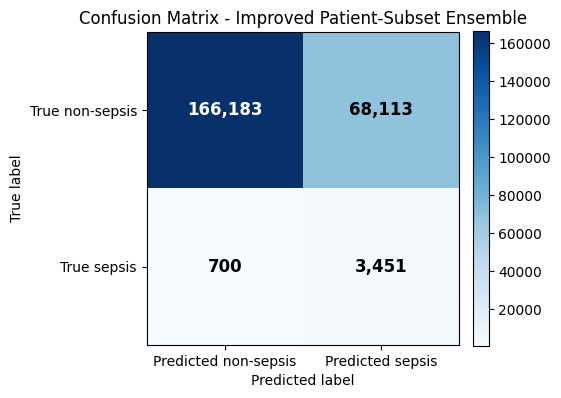

Saved: /kaggle/working/figure_confusion_matrix_improved_pse.png


In [17]:
cm = confusion_matrix(y_test, test_pred, labels=[0, 1])

fig, ax = plt.subplots(figsize=(5.5, 4.8))

im = ax.imshow(cm, cmap="Blues")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Predicted non-sepsis", "Predicted sepsis"])
ax.set_yticklabels(["True non-sepsis", "True sepsis"])

color_threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center",
            color="white" if cm[i, j] > color_threshold else "black",
            fontsize=12,
            fontweight="bold"
        )

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix - Improved Patient-Subset Ensemble")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()

fig_path = "/kaggle/working/figure_confusion_matrix_improved_pse.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

### Precision-Recall curve

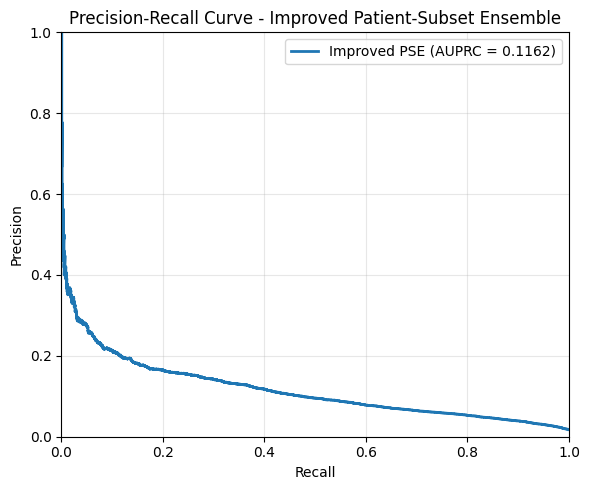

Saved: /kaggle/working/figure_pr_curve_improved_pse.png


In [18]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, ensemble_test_prob)
auprc = average_precision_score(y_test, ensemble_test_prob)

fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(
    recall,
    precision,
    linewidth=2,
    label=f"Improved PSE (AUPRC = {auprc:.4f})"
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve - Improved Patient-Subset Ensemble")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(loc="best")

plt.tight_layout()

fig_path = "/kaggle/working/figure_pr_curve_improved_pse.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

### ROC curve

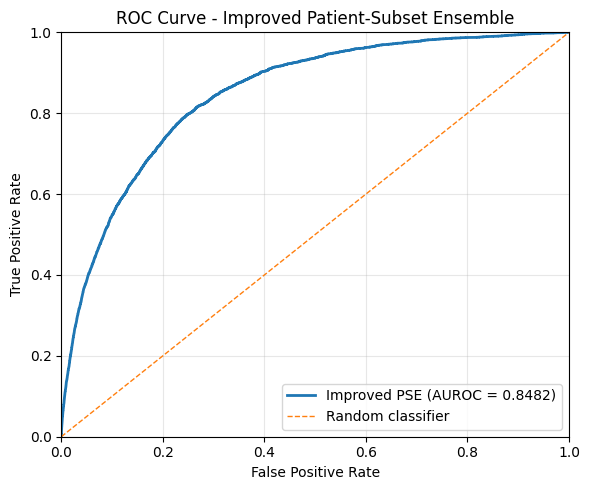

Saved: /kaggle/working/figure_roc_curve_improved_pse.png


In [19]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, ensemble_test_prob)
auroc = roc_auc_score(y_test, ensemble_test_prob)

fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Improved PSE (AUROC = {auroc:.4f})"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Random classifier"
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - Improved Patient-Subset Ensemble")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(loc="best")

plt.tight_layout()

fig_path = "/kaggle/working/figure_roc_curve_improved_pse.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

### Error analysis inputs for the main ensemble model

In [20]:
import numpy as np
import pandas as pd

# Build sequence-level prediction tables 
df_val_pred = pd.DataFrame({
    "row_id": np.arange(len(y_val)),
    "patient_id": id_val,
    "y_true": y_val.astype(int),
    "y_prob": ensemble_val_prob,
})

df_test_pred = pd.DataFrame({
    "row_id": np.arange(len(y_test)),
    "patient_id": id_test,
    "y_true": y_test.astype(int),
    "y_prob": ensemble_test_prob,
})

df_val_pred["y_pred"] = (df_val_pred["y_prob"] >= best_threshold).astype(int)
df_test_pred["y_pred"] = (df_test_pred["y_prob"] >= best_threshold).astype(int)

def error_type(y_true, y_pred):
    if y_true == 1 and y_pred == 1:
        return "TP"
    elif y_true == 1 and y_pred == 0:
        return "FN"
    elif y_true == 0 and y_pred == 1:
        return "FP"
    else:
        return "TN"

df_val_pred["error_type"] = [
    error_type(t, p) for t, p in zip(df_val_pred["y_true"], df_val_pred["y_pred"])
]
df_test_pred["error_type"] = [
    error_type(t, p) for t, p in zip(df_test_pred["y_true"], df_test_pred["y_pred"])
]

# Ensemble disagreement / uncertainty 
df_val_pred["member_prob_std"] = val_probs_array.std(axis=0)
df_val_pred["member_prob_min"] = val_probs_array.min(axis=0)
df_val_pred["member_prob_max"] = val_probs_array.max(axis=0)

df_test_pred["member_prob_std"] = test_probs_array.std(axis=0)
df_test_pred["member_prob_min"] = test_probs_array.min(axis=0)
df_test_pred["member_prob_max"] = test_probs_array.max(axis=0)

print("Validation error types:")
print(df_val_pred["error_type"].value_counts())

print("\nTest error types:")
print(df_test_pred["error_type"].value_counts())

df_val_pred.to_csv("ensemble_val_predictions.csv", index=False)
df_test_pred.to_csv("ensemble_test_predictions.csv", index=False)

print("\nSaved:")
print("- ensemble_val_predictions.csv")
print("- ensemble_test_predictions.csv")

Validation error types:
error_type
TN    131103
FP     56066
TP      2919
FN       709
Name: count, dtype: int64

Test error types:
error_type
TN    166183
FP     68113
TP      3451
FN       700
Name: count, dtype: int64

Saved:
- ensemble_val_predictions.csv
- ensemble_test_predictions.csv


In [21]:
def summarize_error_groups(df):
    return (
        df.groupby("error_type")
          .agg(
              n=("row_id", "size"),
              mean_prob=("y_prob", "mean"),
              median_prob=("y_prob", "median"),
              mean_member_std=("member_prob_std", "mean"),
              n_patients=("patient_id", "nunique"),
          )
          .sort_values("n", ascending=False)
    )

print("Validation summary:")
display(summarize_error_groups(df_val_pred))

print("\nTest summary:")
display(summarize_error_groups(df_test_pred))

Validation summary:


,n,mean_prob,median_prob,mean_member_std,n_patients
error_type,,,,,
TN,131103,0.141167,0.101800,0.076956,6176
FP,56066,0.667331,0.659311,0.100630,4960
TP,2919,0.772786,0.817546,0.062222,377
FN,709,0.232048,0.232002,0.116983,168



Test summary:


,n,mean_prob,median_prob,mean_member_std,n_patients
error_type,,,,,
TN,166183,0.141472,0.101907,0.077279,7752
FP,68113,0.668141,0.659246,0.100757,6243
TP,3451,0.776869,0.823918,0.065243,450
FN,700,0.243391,0.260008,0.113435,182


### Metadata

In [22]:
meta_train = pd.read_csv('/kaggle/input/datasets/thuhiuhong/traintestval-lstm/meta_train (1).csv')
meta_val = pd.read_csv('/kaggle/input/datasets/thuhiuhong/traintestval-lstm/meta_val (1).csv')
meta_test = pd.read_csv('/kaggle/input/datasets/thuhiuhong/traintestval-lstm/meta_test (1).csv')

# Merge on row_id 
df_val_analysis = df_val_pred.merge(
    meta_val,
    on='row_id',
    how='left',
    validate='one_to_one',
    suffixes=('_pred', '_meta')
)

df_test_analysis = df_test_pred.merge(
    meta_test,
    on='row_id',
    how='left',
    validate='one_to_one',
    suffixes=('_pred', '_meta')
)

# Correct merge checks 
assert len(df_val_analysis) == len(df_val_pred)
assert len(df_test_analysis) == len(df_test_pred)

assert (df_val_analysis['patient_id_pred'].values == df_val_analysis['patient_id_meta'].values).all()
assert (df_test_analysis['patient_id_pred'].values == df_test_analysis['patient_id_meta'].values).all()

assert (df_val_analysis['y_true_pred'].values == df_val_analysis['y_true_meta'].values).all()
assert (df_test_analysis['y_true_pred'].values == df_test_analysis['y_true_meta'].values).all()

# Only check metadata columns that should not be missing
assert df_val_analysis['window_end_hour'].isna().sum() == 0
assert df_test_analysis['window_end_hour'].isna().sum() == 0

assert df_val_analysis['raw_missing_rate_window'].isna().sum() == 0
assert df_test_analysis['raw_missing_rate_window'].isna().sum() == 0

# Rename columns back to clean names 
df_val_analysis = df_val_analysis.rename(columns={
    'patient_id_pred': 'patient_id',
    'y_true_pred': 'y_true'
}).drop(columns=['patient_id_meta', 'y_true_meta'])

df_test_analysis = df_test_analysis.rename(columns={
    'patient_id_pred': 'patient_id',
    'y_true_pred': 'y_true'
}).drop(columns=['patient_id_meta', 'y_true_meta'])

print("df_val_analysis:", df_val_analysis.shape)
print("df_test_analysis:", df_test_analysis.shape)

print("\nMissing check:")
print("VAL  - window_end_hour:", df_val_analysis['window_end_hour'].isna().sum())
print("VAL  - raw_missing_rate_window:", df_val_analysis['raw_missing_rate_window'].isna().sum())
print("VAL  - last_HR_raw:", df_val_analysis['last_HR_raw'].isna().sum())

print("TEST - window_end_hour:", df_test_analysis['window_end_hour'].isna().sum())
print("TEST - raw_missing_rate_window:", df_test_analysis['raw_missing_rate_window'].isna().sum())
print("TEST - last_HR_raw:", df_test_analysis['last_HR_raw'].isna().sum())

display(df_val_analysis.head())
display(df_test_analysis.head())

print("Merge check passed.")

df_val_analysis: (190797, 32)
df_test_analysis: (238447, 32)

Missing check:
VAL  - window_end_hour: 0
VAL  - raw_missing_rate_window: 0
VAL  - last_HR_raw: 15881
TEST - window_end_hour: 0
TEST - raw_missing_rate_window: 0
TEST - last_HR_raw: 19889


,row_id,patient_id,y_true,y_prob,y_pred,error_type,member_prob_std,member_prob_min,member_prob_max,seq_index_within_patient,...,last_O2Sat_raw,last_Temp_raw,delta_HR_raw,delta_Resp_raw,delta_SBP_raw,delta_MAP_raw,n_obs_HR_window,n_obs_Resp_window,n_obs_SBP_window,n_obs_MAP_window
0,0,6,0,0.349485,0,TN,0.158507,0.094144,0.536931,0,...,95.0,NaN,-26.5,-7.0,-27.5,-18.0,9,9,9,9
1,1,6,0,0.711097,1,FP,0.185147,0.400546,0.871006,1,...,95.0,NaN,-30.5,-9.0,-47.5,-31.0,10,10,10,10
2,2,6,0,0.739442,1,FP,0.148897,0.530731,0.891808,2,...,95.0,NaN,-22.0,-6.5,-33.0,-16.0,10,10,10,10
3,3,6,0,0.779964,1,FP,0.106412,0.634261,0.908046,3,...,94.5,37.39,-31.0,-3.5,-19.0,4.0,10,10,10,10
4,4,6,0,0.712570,1,FP,0.134329,0.503040,0.863801,4,...,94.0,NaN,-3.0,3.0,-6.0,-9.0,10,10,10,10


,row_id,patient_id,y_true,y_prob,y_pred,error_type,member_prob_std,member_prob_min,member_prob_max,seq_index_within_patient,...,last_O2Sat_raw,last_Temp_raw,delta_HR_raw,delta_Resp_raw,delta_SBP_raw,delta_MAP_raw,n_obs_HR_window,n_obs_Resp_window,n_obs_SBP_window,n_obs_MAP_window
0,0,1,0,0.166434,0,TN,0.078553,0.049912,0.284154,0,...,95.0,36.11,-3.0,-6.5,19.0,12.0,9,9,9,9
1,1,1,0,0.819948,1,FP,0.038754,0.781037,0.873537,1,...,95.0,NaN,-1.0,-4.5,29.0,18.0,10,10,10,10
2,2,1,0,0.778312,1,FP,0.034036,0.743033,0.836510,2,...,94.0,NaN,-4.0,-15.0,15.0,10.0,10,10,10,10
3,3,1,0,0.654701,1,FP,0.066612,0.572141,0.764628,3,...,95.0,NaN,6.0,3.0,16.0,7.0,10,10,10,10
4,4,1,0,0.450869,1,FP,0.103501,0.311993,0.570503,4,...,95.0,NaN,-3.0,-12.0,23.0,8.0,10,10,10,10


Merge check passed.


In [23]:
# Dense test distribution and AUPRC baseline

required_cols = ["patient_id", "y_true", "y_prob", "y_pred"]
missing_cols = [c for c in required_cols if c not in df_test_pred.columns]
assert len(missing_cols) == 0, f"Missing columns: {missing_cols}"

n_windows = len(df_test_pred)
n_pos = int(df_test_pred["y_true"].sum())
n_neg = n_windows - n_pos
positive_rate = n_pos / n_windows

auroc = roc_auc_score(df_test_pred["y_true"], df_test_pred["y_prob"])
auprc = average_precision_score(df_test_pred["y_true"], df_test_pred["y_prob"])
auprc_lift = auprc / positive_rate

print("Dense test distribution")
print("Total windows :", n_windows)
print("Positive      :", n_pos)
print("Negative      :", n_neg)
print("Positive rate :", positive_rate)

print("\nRanking metrics")
print("AUROC         :", auroc)
print("AUPRC         :", auprc)
print("AUPRC baseline:", positive_rate)
print("AUPRC lift    :", auprc_lift)

Dense test distribution
Total windows : 238447
Positive      : 4151
Negative      : 234296
Positive rate : 0.01740848071059816

Ranking metrics
AUROC         : 0.8482455603047312
AUPRC         : 0.11623698752604973
AUPRC baseline: 0.01740848071059816
AUPRC lift    : 6.677032272855693


In [24]:
# Fixed missingness cutoff from TRAIN 
missing_cutoff = meta_train['raw_missing_rate_window'].median()
print("missing_cutoff from train =", missing_cutoff)

missing_cutoff from train = 0.1666666666666666


In [25]:
# Create clinically meaningful subgroups 

for df in [df_val_analysis, df_test_analysis]:
    df['hr_high'] = (df['last_HR_raw'] >= 100).astype(int)
    df['resp_high'] = (df['last_Resp_raw'] >= 22).astype(int)
    df['sbp_low'] = (df['last_SBP_raw'] <= 100).astype(int)
    df['map_low'] = (df['last_MAP_raw'] < 65).astype(int)

    # Use the fixed cutoff from TRAIN
    df['missing_high'] = (df['raw_missing_rate_window'] >= missing_cutoff).astype(int)

    df['delta_hr_up'] = (df['delta_HR_raw'] > 0).astype(int)
    df['delta_resp_up'] = (df['delta_Resp_raw'] > 0).astype(int)
    df['delta_sbp_down'] = (df['delta_SBP_raw'] < 0).astype(int)
    df['delta_map_down'] = (df['delta_MAP_raw'] < 0).astype(int)

    df['eda_pattern_strong'] = (
        (df['delta_hr_up'] == 1) &
        (df['delta_resp_up'] == 1) &
        (
            (df['delta_sbp_down'] == 1) |
            (df['delta_map_down'] == 1)
        )
    ).astype(int)

print("Done creating subgroup flags.")
print("Using fixed missing_cutoff from train:", missing_cutoff)

Done creating subgroup flags.
Using fixed missing_cutoff from train: 0.1666666666666666


In [26]:
def subgroup_report(df, group_col):
    rows = []

    for group_value, sub in df.groupby(group_col):
        y_true = sub['y_true'].values
        y_prob = sub['y_prob'].values
        y_pred = sub['y_pred'].values

        if len(np.unique(y_true)) < 2:
            auprc = np.nan
        else:
            auprc = average_precision_score(y_true, y_prob)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        precision = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        rows.append({
            'group': group_value,
            'n': len(sub),
            'positive_rate': sub['y_true'].mean(),
            'AUPRC': auprc,
            'sensitivity': sensitivity,
            'specificity': specificity,
            'precision': precision,
            'f1': f1,
            'FP': fp,
            'FN': fn,
            'TP': tp,
            'TN': tn,
            'mean_prob': sub['y_prob'].mean(),
            'mean_member_std': sub['member_prob_std'].mean()
        })

    return pd.DataFrame(rows).sort_values('group')

In [27]:
# First subgroup analyses 

report_pattern_val = subgroup_report(df_val_analysis, 'eda_pattern_strong')
report_pattern_test = subgroup_report(df_test_analysis, 'eda_pattern_strong')

report_missing_val = subgroup_report(df_val_analysis, 'missing_high')
report_missing_test = subgroup_report(df_test_analysis, 'missing_high')

report_hr_val = subgroup_report(df_val_analysis, 'hr_high')
report_hr_test = subgroup_report(df_test_analysis, 'hr_high')

print("Validation - EDA pattern strong")
display(report_pattern_val)

print("Test - EDA pattern strong")
display(report_pattern_test)

print("Validation - Missing high")
display(report_missing_val)

print("Test - Missing high")
display(report_missing_test)

print("Validation - HR high")
display(report_hr_val)

print("Test - HR high")
display(report_hr_test)

Validation - EDA pattern strong


,group,n,positive_rate,AUPRC,sensitivity,specificity,precision,f1,FP,FN,TP,TN,mean_prob,mean_member_std
0,0,168236,0.018510,0.105447,0.799615,0.702135,0.048187,0.090896,49184,624,2490,115938,0.304113,0.083501
1,1,22561,0.022783,0.126670,0.834630,0.687849,0.058679,0.109649,6882,85,429,15165,0.318231,0.086336


Test - EDA pattern strong


,group,n,positive_rate,AUPRC,sensitivity,specificity,precision,f1,FP,FN,TP,TN,mean_prob,mean_member_std
0,0,210147,0.016964,0.117142,0.833661,0.710875,0.047400,0.089700,59728,593,2972,146854,0.300032,0.083755
1,1,28300,0.020707,0.112687,0.817406,0.697445,0.054039,0.101376,8385,107,479,19329,0.311656,0.085120


Validation - Missing high


...

,group,n,positive_rate,AUPRC,sensitivity,specificity,precision,f1,FP,FN,TP,TN,mean_prob,mean_member_std
0,0,125558,0.017761,0.115061,0.844395,0.686949,0.046504,0.088153,38608,347,1883,84720,0.319893,0.087438
1,1,112889,0.017017,0.119832,0.816242,0.734113,0.050462,0.095048,29505,353,1568,81463,0.280855,0.080002


Validation - HR high


,group,n,positive_rate,AUPRC,sensitivity,specificity,precision,f1,FP,FN,TP,TN,mean_prob,mean_member_std
0,0,158492,0.016733,0.099781,0.801659,0.722517,0.04686,0.088545,43243,526,2126,112597,0.289224,0.081553
1,1,32305,0.030212,0.134893,0.812500,0.590699,0.05824,0.108690,12823,183,793,18506,0.387019,0.095037


Test - HR high


,group,n,positive_rate,AUPRC,sensitivity,specificity,precision,f1,FP,FN,TP,TN,mean_prob,mean_member_std
0,0,198268,0.015151,0.106452,0.819241,0.732844,0.045051,0.085405,52166,543,2461,143098,0.283002,0.081800
1,1,40179,0.028547,0.142387,0.863121,0.591438,0.058452,0.109489,15947,157,990,23085,0.392253,0.094367


In [28]:
print("Current validation error counts:")
print(df_val_analysis['error_type'].value_counts())

print("\nCurrent test error counts:")
print(df_test_analysis['error_type'].value_counts())

Current validation error counts:
error_type
TN    131103
FP     56066
TP      2919
FN       709
Name: count, dtype: int64

Current test error counts:
error_type
TN    166183
FP     68113
TP      3451
FN       700
Name: count, dtype: int64


In [29]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(
    df_test_analysis['y_true'],
    df_test_analysis['y_pred'],
    labels=[0, 1]
).ravel()

print("TN, FP, FN, TP =", tn, fp, fn, tp)

TN, FP, FN, TP = 166183 68113 700 3451


### FN and FP by subgroup.

In [30]:
def fn_report(df, group_col):
    rows = []

    for group_value, sub in df.groupby(group_col):
        pos = sub[sub['y_true'] == 1].copy()   # Only evaluate true positive windows
        n_pos = len(pos)

        fn = (pos['error_type'] == 'FN').sum()
        tp = (pos['error_type'] == 'TP').sum()

        fn_rate = fn / n_pos if n_pos > 0 else np.nan
        tp_rate = tp / n_pos if n_pos > 0 else np.nan

        fn_sub = pos[pos['error_type'] == 'FN']

        rows.append({
            'group': group_value,
            'n_total': len(sub),
            'n_positive': n_pos,
            'FN': fn,
            'TP': tp,
            'FN_rate_within_positive': fn_rate,
            'TP_rate_within_positive': tp_rate,
            'mean_prob_positive': pos['y_prob'].mean() if n_pos > 0 else np.nan,
            'mean_prob_FN': fn_sub['y_prob'].mean() if len(fn_sub) > 0 else np.nan,
            'mean_member_std_FN': fn_sub['member_prob_std'].mean() if len(fn_sub) > 0 else np.nan,
        })

    return pd.DataFrame(rows).sort_values('group')

In [31]:
def fp_report(df, group_col):
    rows = []

    for group_value, sub in df.groupby(group_col):
        neg = sub[sub['y_true'] == 0].copy()   # Only evaluate true negative windows
        n_neg = len(neg)

        fp = (neg['error_type'] == 'FP').sum()
        tn = (neg['error_type'] == 'TN').sum()

        fp_rate = fp / n_neg if n_neg > 0 else np.nan
        tn_rate = tn / n_neg if n_neg > 0 else np.nan

        fp_sub = neg[neg['error_type'] == 'FP']

        rows.append({
            'group': group_value,
            'n_total': len(sub),
            'n_negative': n_neg,
            'FP': fp,
            'TN': tn,
            'FP_rate_within_negative': fp_rate,
            'TN_rate_within_negative': tn_rate,
            'mean_prob_negative': neg['y_prob'].mean() if n_neg > 0 else np.nan,
            'mean_prob_FP': fp_sub['y_prob'].mean() if len(fp_sub) > 0 else np.nan,
            'mean_member_std_FP': fp_sub['member_prob_std'].mean() if len(fp_sub) > 0 else np.nan,
        })

    return pd.DataFrame(rows).sort_values('group')

In [32]:
# FN reports on test 
fn_pattern_test = fn_report(df_test_analysis, 'eda_pattern_strong')
fn_missing_test = fn_report(df_test_analysis, 'missing_high')
fn_hr_test = fn_report(df_test_analysis, 'hr_high')
fn_resp_test = fn_report(df_test_analysis, 'resp_high')
fn_sbp_test = fn_report(df_test_analysis, 'sbp_low')
fn_map_test = fn_report(df_test_analysis, 'map_low')

print("Test - FN by EDA pattern strong")
display(fn_pattern_test)

print("Test - FN by Missing high")
display(fn_missing_test)

print("Test - FN by HR high")
display(fn_hr_test)

print("Test - FN by Resp high")
display(fn_resp_test)

print("Test - FN by SBP low")
display(fn_sbp_test)

print("Test - FN by MAP low")
display(fn_map_test)

Test - FN by EDA pattern strong


,group,n_total,n_positive,FN,TP,FN_rate_within_positive,TP_rate_within_positive,mean_prob_positive,mean_prob_FN,mean_member_std_FN
0,0,210147,3565,593,2972,0.166339,0.833661,0.688044,0.248329,0.115637
1,1,28300,586,107,479,0.182594,0.817406,0.679986,0.216026,0.101232


Test - FN by Missing high


,group,n_total,n_positive,FN,TP,FN_rate_within_positive,TP_rate_within_positive,mean_prob_positive,mean_prob_FN,mean_member_std_FN
0,0,125558,2230,347,1883,0.155605,0.844395,0.700096,0.263153,0.120562
1,1,112889,1921,353,1568,0.183758,0.816242,0.671596,0.223965,0.106430


Test - FN by HR high


...

,group,n_total,n_positive,FN,TP,FN_rate_within_positive,TP_rate_within_positive,mean_prob_positive,mean_prob_FN,mean_member_std_FN
0,0,185949,2689,526,2163,0.195612,0.804388,0.661527,0.235133,0.112655
1,1,52498,1462,174,1288,0.119015,0.880985,0.733587,0.268357,0.115793


Test - FN by SBP low


,group,n_total,n_positive,FN,TP,FN_rate_within_positive,TP_rate_within_positive,mean_prob_positive,mean_prob_FN,mean_member_std_FN
0,0,207472,3460,601,2859,0.173699,0.826301,0.683873,0.244437,0.113152
1,1,30975,691,99,592,0.143271,0.856729,0.702098,0.237040,0.115156


Test - FN by MAP low


,group,n_total,n_positive,FN,TP,FN_rate_within_positive,TP_rate_within_positive,mean_prob_positive,mean_prob_FN,mean_member_std_FN
0,0,215047,3602,633,2969,0.175736,0.824264,0.681111,0.240043,0.113704
1,1,23400,549,67,482,0.122040,0.877960,0.724933,0.275022,0.110889


In [33]:
# FP reports on test 
fp_pattern_test = fp_report(df_test_analysis, 'eda_pattern_strong')
fp_missing_test = fp_report(df_test_analysis, 'missing_high')
fp_hr_test = fp_report(df_test_analysis, 'hr_high')
fp_resp_test = fp_report(df_test_analysis, 'resp_high')
fp_sbp_test = fp_report(df_test_analysis, 'sbp_low')
fp_map_test = fp_report(df_test_analysis, 'map_low')

print("Test - FP by EDA pattern strong")
display(fp_pattern_test)

print("Test - FP by Missing high")
display(fp_missing_test)

print("Test - FP by HR high")
display(fp_hr_test)

print("Test - FP by Resp high")
display(fp_resp_test)

print("Test - FP by SBP low")
display(fp_sbp_test)

print("Test - FP by MAP low")
display(fp_map_test)

Test - FP by EDA pattern strong


,group,n_total,n_negative,FP,TN,FP_rate_within_negative,TN_rate_within_negative,mean_prob_negative,mean_prob_FP,mean_member_std_FP
0,0,210147,206582,59728,146854,0.289125,0.710875,0.293336,0.66711,0.100767
1,1,28300,27714,8385,19329,0.302555,0.697445,0.303868,0.67548,0.100682


Test - FP by Missing high


,group,n_total,n_negative,FP,TN,FP_rate_within_negative,TN_rate_within_negative,mean_prob_negative,mean_prob_FP,mean_member_std_FP
0,0,125558,123328,38608,84720,0.313051,0.686949,0.313018,0.668929,0.099095
1,1,112889,110968,29505,81463,0.265887,0.734113,0.274091,0.667109,0.102932


Test - FP by HR high


...

,group,n_total,n_negative,FP,TN,FP_rate_within_negative,TN_rate_within_negative,mean_prob_negative,mean_prob_FP,mean_member_std_FP
0,0,185949,183260,48519,134741,0.264755,0.735245,0.274863,0.659292,0.103425
1,1,52498,51036,19594,31442,0.383925,0.616075,0.365385,0.690052,0.094151


Test - FP by SBP low


,group,n_total,n_negative,FP,TN,FP_rate_within_negative,TN_rate_within_negative,mean_prob_negative,mean_prob_FP,mean_member_std_FP
0,0,207472,204012,56241,147771,0.275675,0.724325,0.283400,0.666903,0.099580
1,1,30975,30284,11872,18412,0.392022,0.607978,0.369904,0.674005,0.106335


Test - FP by MAP low


,group,n_total,n_negative,FP,TN,FP_rate_within_negative,TN_rate_within_negative,mean_prob_negative,mean_prob_FP,mean_member_std_FP
0,0,215047,211445,58704,152741,0.277632,0.722368,0.284924,0.668281,0.100025
1,1,23400,22851,9409,13442,0.411754,0.588246,0.383945,0.667266,0.105323


## Case studies of the main model at the window level

In [34]:
# Select a representative TP window near onset 

tp_candidates = df_test_analysis[
    (df_test_analysis['error_type'] == 'TP') &
    (df_test_analysis['is_sepsis_patient'] == 1) &
    (df_test_analysis['hours_to_onset'] >= 0) &
    (df_test_analysis['hours_to_onset'] <= 6) &
    (
        (df_test_analysis['hr_high'] == 1) |
        (df_test_analysis['resp_high'] == 1) |
        (df_test_analysis['sbp_low'] == 1) |
        (df_test_analysis['map_low'] == 1)
    )
].copy()

tp_candidates = tp_candidates.sort_values(
    ['y_prob', 'member_prob_std'],
    ascending=[False, True]
)

print("Number of TP candidates:", len(tp_candidates))

tp_case = tp_candidates.iloc[0]

display(pd.DataFrame([tp_case])[[
    'patient_id', 'row_id', 'error_type', 'y_true', 'y_pred', 'y_prob',
    'member_prob_std', 'window_start_hour', 'window_end_hour',
    'onset_hour', 'hours_to_onset', 'raw_missing_rate_window',
    'last_HR_raw', 'last_Resp_raw', 'last_SBP_raw', 'last_MAP_raw',
    'hr_high', 'resp_high', 'sbp_low', 'map_low', 'missing_high',
    'eda_pattern_strong'
]])

Number of TP candidates: 183


,patient_id,row_id,error_type,y_true,y_pred,y_prob,member_prob_std,window_start_hour,window_end_hour,onset_hour,...,last_HR_raw,last_Resp_raw,last_SBP_raw,last_MAP_raw,hr_high,resp_high,sbp_low,map_low,missing_high,eda_pattern_strong
86062,14528,86062,TP,1,1,0.938941,0.026185,1,10,10.0,...,110.0,16.0,112.0,71.0,1,0,0,0,1,0


In [35]:
# Select a representative FN window near onset 

fn_candidates = df_test_analysis[
    (df_test_analysis['error_type'] == 'FN') &
    (df_test_analysis['is_sepsis_patient'] == 1) &
    (df_test_analysis['hours_to_onset'] >= 0) &
    (df_test_analysis['hours_to_onset'] <= 6)
].copy()

# Prioritize missingness-related failure modes, followed by strong EDA patterns
fn_candidates = fn_candidates.sort_values(
    ['missing_high', 'eda_pattern_strong', 'y_prob', 'member_prob_std'],
    ascending=[False, False, False, True]
)

print("Number of FN candidates:", len(fn_candidates))

fn_case = fn_candidates.iloc[0]

display(pd.DataFrame([fn_case])[[
    'patient_id', 'row_id', 'error_type', 'y_true', 'y_pred', 'y_prob',
    'member_prob_std', 'window_start_hour', 'window_end_hour',
    'onset_hour', 'hours_to_onset', 'raw_missing_rate_window',
    'last_HR_raw', 'last_Resp_raw', 'last_SBP_raw', 'last_MAP_raw',
    'hr_high', 'resp_high', 'sbp_low', 'map_low', 'missing_high',
    'eda_pattern_strong'
]])

Number of FN candidates: 80


,patient_id,row_id,error_type,y_true,y_pred,y_prob,member_prob_std,window_start_hour,window_end_hour,onset_hour,...,last_HR_raw,last_Resp_raw,last_SBP_raw,last_MAP_raw,hr_high,resp_high,sbp_low,map_low,missing_high,eda_pattern_strong
104798,18012,104798,FN,1,0,0.331702,0.237816,0,9,9.0,...,96.0,27.0,122.0,87.17,0,1,0,0,1,1


In [36]:
# Select a representative FP window on a non-sepsis patient 

fp_candidates = df_test_analysis[
    (df_test_analysis['error_type'] == 'FP') &
    (df_test_analysis['is_sepsis_patient'] == 0) &
    (
        (df_test_analysis['hr_high'] == 1) |
        (df_test_analysis['resp_high'] == 1) |
        (df_test_analysis['sbp_low'] == 1) |
        (df_test_analysis['map_low'] == 1)
    )
].copy()

fp_candidates = fp_candidates.sort_values(
    ['y_prob', 'member_prob_std'],
    ascending=[False, True]
)

print("Number of FP candidates:", len(fp_candidates))

fp_case = fp_candidates.iloc[0]

display(pd.DataFrame([fp_case])[[
    'patient_id', 'row_id', 'error_type', 'y_true', 'y_pred', 'y_prob',
    'member_prob_std', 'window_start_hour', 'window_end_hour',
    'onset_hour', 'hours_to_onset', 'raw_missing_rate_window',
    'last_HR_raw', 'last_Resp_raw', 'last_SBP_raw', 'last_MAP_raw',
    'hr_high', 'resp_high', 'sbp_low', 'map_low', 'missing_high',
    'eda_pattern_strong'
]])

Number of FP candidates: 27605


,patient_id,row_id,error_type,y_true,y_pred,y_prob,member_prob_std,window_start_hour,window_end_hour,onset_hour,...,last_HR_raw,last_Resp_raw,last_SBP_raw,last_MAP_raw,hr_high,resp_high,sbp_low,map_low,missing_high,eda_pattern_strong
194891,32932,194891,FP,0,1,0.955666,0.015772,24,33,NaN,...,110.0,NaN,90.0,67.0,1,0,1,0,1,0


In [37]:
# Summary of the refined case-study set

selected_cases = pd.DataFrame([
    tp_case,
    fn_case,
    fp_case
]).copy()

selected_cases.index = ['TP_case', 'FN_case', 'FP_case']

display(selected_cases[[
    'patient_id', 'row_id', 'error_type', 'y_true', 'y_pred', 'y_prob',
    'member_prob_std', 'window_start_hour', 'window_end_hour',
    'onset_hour', 'hours_to_onset', 'raw_missing_rate_window',
    'last_HR_raw', 'last_Resp_raw', 'last_SBP_raw', 'last_MAP_raw',
    'hr_high', 'resp_high', 'sbp_low', 'map_low', 'missing_high',
    'eda_pattern_strong'
]])

,patient_id,row_id,error_type,y_true,y_pred,y_prob,member_prob_std,window_start_hour,window_end_hour,onset_hour,...,last_HR_raw,last_Resp_raw,last_SBP_raw,last_MAP_raw,hr_high,resp_high,sbp_low,map_low,missing_high,eda_pattern_strong
TP_case,14528,86062,TP,1,1,0.938941,0.026185,1,10,10.0,...,110.0,16.0,112.0,71.00,1,0,0,0,1,0
FN_case,18012,104798,FN,1,0,0.331702,0.237816,0,9,9.0,...,96.0,27.0,122.0,87.17,0,1,0,0,1,1
FP_case,32932,194891,FP,0,1,0.955666,0.015772,24,33,NaN,...,110.0,NaN,90.0,67.00,1,0,1,0,1,0


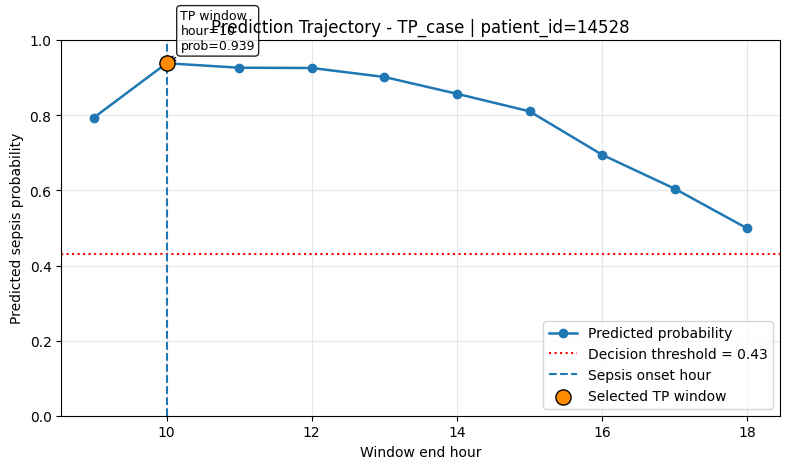

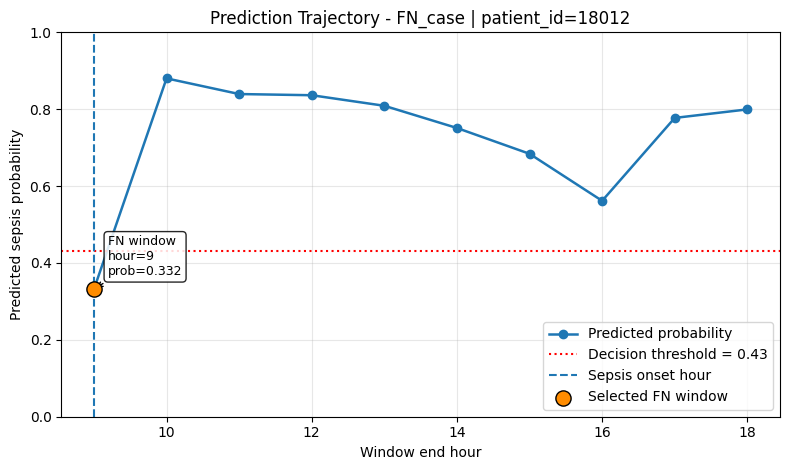

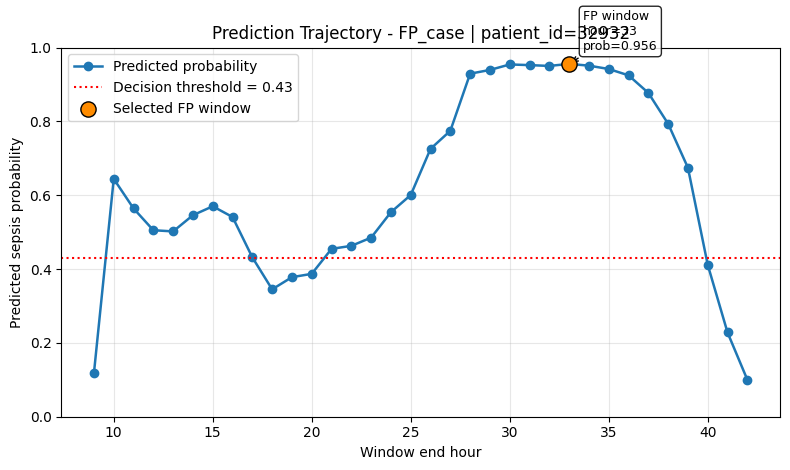

In [38]:
# Plot prediction trajectories for the selected case-study patients
DECISION_THRESHOLD = best_threshold

for case_name, case_row in selected_cases.iterrows():
    patient_id = case_row["patient_id"]

    patient_df = (
        df_test_analysis[df_test_analysis["patient_id"] == patient_id]
        .sort_values("window_end_hour")
        .copy()
    )

    fig, ax = plt.subplots(figsize=(8, 4.8))

    ax.plot(
        patient_df["window_end_hour"],
        patient_df["y_prob"],
        marker="o",
        linewidth=1.8,
        label="Predicted probability",
    )

    # Decision threshold
    ax.axhline(
        DECISION_THRESHOLD,
        linestyle=":",
        linewidth=1.5,
        color="red",
        label=f"Decision threshold = {DECISION_THRESHOLD:.2f}",
    )

    # Sepsis onset line for sepsis patients
    if pd.notna(case_row["onset_hour"]):
        ax.axvline(
            case_row["onset_hour"],
            linestyle="--",
            linewidth=1.5,
            color="tab:blue",
            label="Sepsis onset hour",
        )

    # Highlight selected case-study window
    ax.scatter(
        [case_row["window_end_hour"]],
        [case_row["y_prob"]],
        s=120,
        color="darkorange",
        edgecolor="black",
        zorder=5,
        label=f"Selected {case_row['error_type']} window",
    )

    # Annotate selected window
    ax.annotate(
        (
            f"{case_row['error_type']} window\n"
            f"hour={case_row['window_end_hour']:.0f}\n"
            f"prob={case_row['y_prob']:.3f}"
        ),
        xy=(case_row["window_end_hour"], case_row["y_prob"]),
        xytext=(10, 10),
        textcoords="offset points",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85),
        arrowprops=dict(arrowstyle="->", lw=1),
    )

    ax.set_xlabel("Window end hour")
    ax.set_ylabel("Predicted sepsis probability")
    ax.set_title(f"Prediction Trajectory - {case_name} | patient_id={patient_id}")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), loc="best")

    plt.tight_layout()
    plt.show()

### Subgroup performance

In [39]:
from sklearn.metrics import average_precision_score

def compute_metrics(df):
    y_true = df['y_true']
    y_pred = df['y_pred']
    y_prob = df['y_prob']
    
    tp = ((y_true == 1) & (y_pred == 1)).sum()
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    tn = ((y_true == 0) & (y_pred == 0)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    
    try:
        auprc = average_precision_score(y_true, y_prob)
    except:
        auprc = np.nan
    
    return pd.Series({
        'n': len(df),
        'positive_rate': y_true.mean(),
        'sensitivity': sensitivity,
        'specificity': specificity,
        'AUPRC': auprc,
        'mean_pred_prob': y_prob.mean()
    })


subgroups = [
    'hr_high',
    'resp_high',
    'sbp_low',
    'map_low',
    'missing_high',
    'eda_pattern_strong'
]

rows = []

for sg in subgroups:
    for val in [0, 1]:
        df_sub = df_test_analysis[df_test_analysis[sg] == val]
        
        metrics = compute_metrics(df_sub)
        metrics['subgroup'] = sg
        metrics['value'] = val
        
        rows.append(metrics)

df_subgroup_table = pd.DataFrame(rows)

df_subgroup_table = df_subgroup_table[
    ['subgroup', 'value', 'n', 'positive_rate', 'sensitivity', 'specificity', 'AUPRC', 'mean_pred_prob']
].sort_values(['subgroup', 'value'])

display(df_subgroup_table)

,subgroup,value,n,positive_rate,sensitivity,specificity,AUPRC,mean_pred_prob
10,eda_pattern_strong,0,210147.0,0.016964,0.833661,0.710875,0.117142,0.300032
11,eda_pattern_strong,1,28300.0,0.020707,0.817406,0.697445,0.112687,0.311656
0,hr_high,0,198268.0,0.015151,0.819241,0.732844,0.106452,0.283002
1,hr_high,1,40179.0,0.028547,0.863121,0.591438,0.142387,0.392253
6,map_low,0,215047.0,0.016750,0.824264,0.722368,0.109817,0.291560
7,map_low,1,23400.0,0.023462,0.877960,0.588246,0.160085,0.391945
8,missing_high,0,125558.0,0.017761,0.844395,0.686949,0.115061,0.319893
9,missing_high,1,112889.0,0.017017,0.816242,0.734113,0.119832,0.280855
2,resp_high,0,185949.0,0.014461,0.804388,0.735245,0.107645,0.280455
3,resp_high,1,52498.0,0.027849,0.880985,0.616075,0.133154,0.375639


In [40]:
df_subgroup_table.to_csv('/kaggle/working/subgroup_performance_table.csv', index=False)

### FN/FP by missingness

In [41]:
rows = []

for val in [0, 1]:
    df_sub = df_test_analysis[df_test_analysis['missing_high'] == val]
    
    # positive group
    df_pos = df_sub[df_sub['y_true'] == 1]
    fn_rate = ((df_pos['y_pred'] == 0).sum() / len(df_pos)) if len(df_pos) > 0 else np.nan
    
    # negative group
    df_neg = df_sub[df_sub['y_true'] == 0]
    fp_rate = ((df_neg['y_pred'] == 1).sum() / len(df_neg)) if len(df_neg) > 0 else np.nan
    
    mean_prob = df_sub['y_prob'].mean()
    
    rows.append({
        'missing_high': val,
        'n': len(df_sub),
        'FN_rate_within_positive': fn_rate,
        'FP_rate_within_negative': fp_rate,
        'mean_pred_prob': mean_prob
    })

df_missing_table = pd.DataFrame(rows)

display(df_missing_table)

,missing_high,n,FN_rate_within_positive,FP_rate_within_negative,mean_pred_prob
0,0,125558,0.155605,0.313051,0.319893
1,1,112889,0.183758,0.265887,0.280855


In [42]:
df_missing_table.to_csv('/kaggle/working/missingness_error_table.csv', index=False)

In [43]:
# Alarm burden analysis

tp = int(((df_test_pred["y_true"] == 1) & (df_test_pred["y_pred"] == 1)).sum())
fp = int(((df_test_pred["y_true"] == 0) & (df_test_pred["y_pred"] == 1)).sum())
fn = int(((df_test_pred["y_true"] == 1) & (df_test_pred["y_pred"] == 0)).sum())
tn = int(((df_test_pred["y_true"] == 0) & (df_test_pred["y_pred"] == 0)).sum())

total_alerts = tp + fp
alert_rate = total_alerts / len(df_test_pred)
fp_per_1000_windows = fp / len(df_test_pred) * 1000
alerts_per_1000_windows = total_alerts / len(df_test_pred) * 1000

print("Alert burden")
print("Total alerts:", total_alerts)
print("True positive alerts:", tp)
print("False positive alerts:", fp)
print("Alert rate:", alert_rate)
print("Alerts per 1000 hourly windows:", alerts_per_1000_windows)
print("False positives per 1000 hourly windows:", fp_per_1000_windows)

fp_by_patient = (
    df_test_pred.assign(fp=((df_test_pred["y_true"] == 0) & (df_test_pred["y_pred"] == 1)).astype(int))
    .groupby("patient_id")["fp"]
    .sum()
)

patients_with_fp = int((fp_by_patient > 0).sum())
total_patients = fp_by_patient.shape[0]

print("\nPatient-level false positive burden")
print("Total patients:", total_patients)
print("Patients with at least one FP:", patients_with_fp)
print("Proportion of patients with at least one FP:", patients_with_fp / total_patients)
print("Mean FP windows per patient:", fp_by_patient.mean())
print("Median FP windows per patient:", fp_by_patient.median())

Alert burden
Total alerts: 71564
True positive alerts: 3451
False positive alerts: 68113
Alert rate: 0.30012539474180844
Alerts per 1000 hourly windows: 300.12539474180846
False positives per 1000 hourly windows: 285.6525768829132

Patient-level false positive burden
Total patients: 7964
Patients with at least one FP: 6243
Proportion of patients with at least one FP: 0.7839025615268709
Mean FP windows per patient: 8.552611752887996
Median FP windows per patient: 3.0
